## SARIMA Model - Time Series Analysis (Series 4)
### Objective
This notebook analyzes the time series of Faringoamigdalitis cases (0–14 years, BCN Nord) using the Box-Jenkins methodology, including model fitting, validation and forecasting, using weekly data in period: 2012-2024

### Methodology
1. Exploratory analysis
2. Stationarity analysis
3. Model identification
4. Model estimation
5. Validation
6. Forecasting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels
import statsmodels.api as sm
import skforecast
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from skforecast.datasets import fetch_dataset
from skforecast.plot import set_dark_theme, plot_prediction_intervals
from skforecast.stats import Sarimax, Arima
from skforecast.recursive import ForecasterStats
from skforecast.utils import expand_index
from skforecast.model_selection import TimeSeriesFold, backtesting_stats, grid_search_stats

warnings.filterwarnings('once')
warnings.filterwarnings('ignore', category=DeprecationWarning)

COLOR_TRAIN = '#1f77b4'   
COLOR_OBS = '#ffbf00'      
COLOR_FORECAST = '#6a0dad' 
COLOR_PINK = '#f4a7b9'  
COLOR_GREEN = '#0b6623' 

df = pd.read_csv("dades_net.csv", sep=",")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["nom_regio", "diagnostic", "edat_bin", "date"]).copy()

### Data Filtering

Is it selected the subset corresponding to:
- Diagnosis: Faringoamigdalitis
- Region: Barcelona Metropolitana Nord
- Age group: 0–14

In [2]:
df_serie = df[
    (df["diagnostic"] == "Faringoamigdalitis") &
    (df["nom_regio"] == "Barcelona Metropolitana Nord") &
    (df["edat_bin"] == "0-14")
]

serie = (
    df_serie.groupby("date")["taxa_setmanal"].sum().sort_index()
)
serie = serie.asfreq("W-MON")

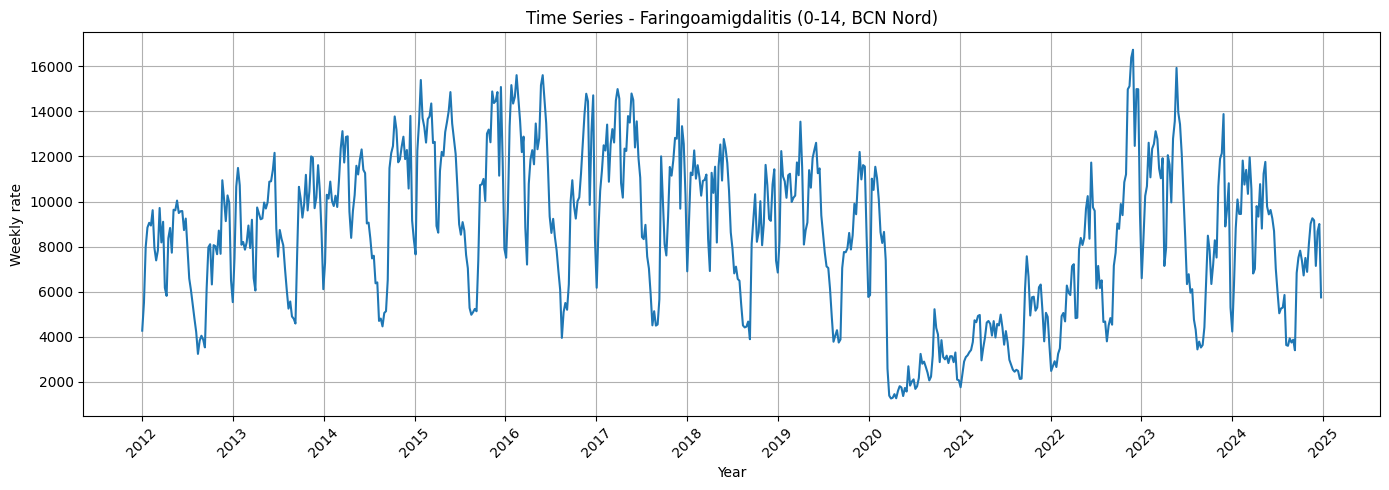

In [3]:
plt.figure(figsize=(14,5))
plt.plot(serie.index, serie.values)

plt.title("Time Series - Faringoamigdalitis (0-14, BCN Nord)")
plt.ylabel("Weekly rate")
plt.xlabel("Year")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Train-Test Split

The dataset is split into:
- Training set: used for model estimation (2012-2019)
- Test set: used for validation and forecasting performance (2020-2024)

In [4]:
serie_4 = serie.copy()

train = serie_4[serie_4.index < "2020-01-01"]
test  = serie_4[serie_4.index >= "2020-01-01"]

#Missing weekly values are linearly interpolated to preserve regular frequency before modeling.
train = train.interpolate()
test = test.interpolate()

2012-01-02 00:00:00 2019-12-30 00:00:00
2020-01-06 00:00:00 2024-12-23 00:00:00


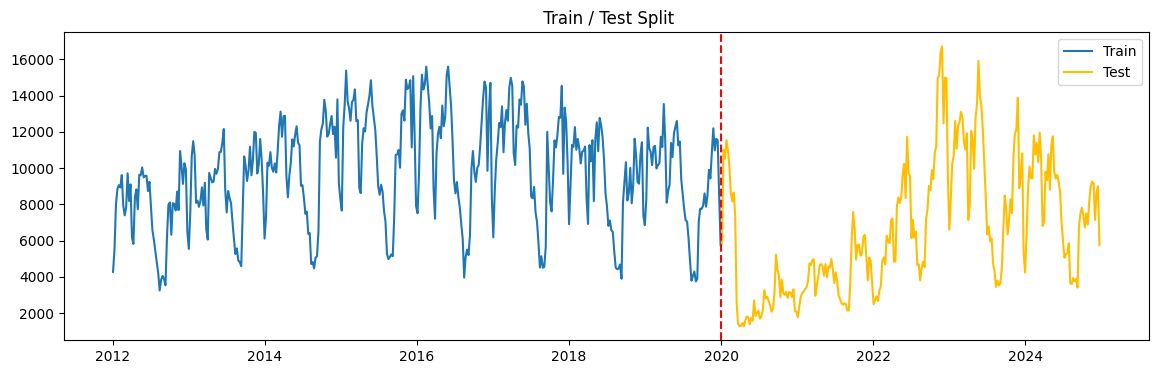

In [5]:
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

plt.figure(figsize=(14,4))

plt.plot(train, label="Train", color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label="Test", color=COLOR_OBS, linewidth=1.5)

plt.axvline(train.index.max(), color="red", linestyle="--")

plt.legend()
plt.title(" Train / Test Split")
plt.show()

## Exploratory Analysis

The time series shows:
- Possible trend
- Seasonality
- Variability over time

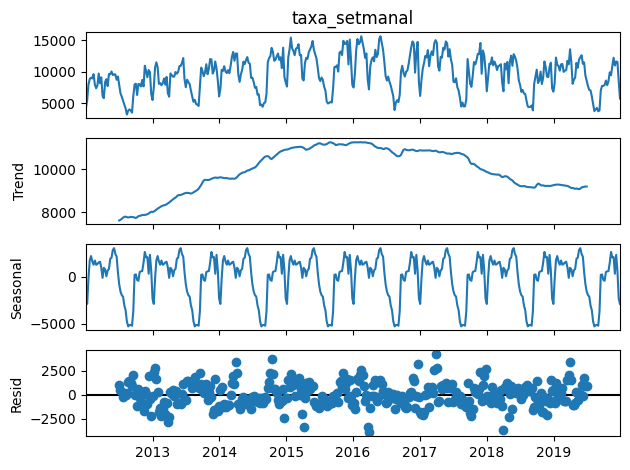

In [6]:
decomp = seasonal_decompose(train, model="additive", period=52)
decomp.plot()
plt.show()

Notice that a log/Box-Cox transformation was tested to stabilize variance. However, no significant improvement was observed in rolling variance, model selection (ACF/PACF), or predictive performance.

Therefore, the original scale of the series was retained.

### Original ACF

After the decomposition, the ACF of the original series is examined to assess the possible presence of seasonality.

Significant peaks at seasonal lags, particularly around \(m = 52\), suggest a clear annual seasonal pattern. This provides an initial indication that seasonal differencing may be needed. 

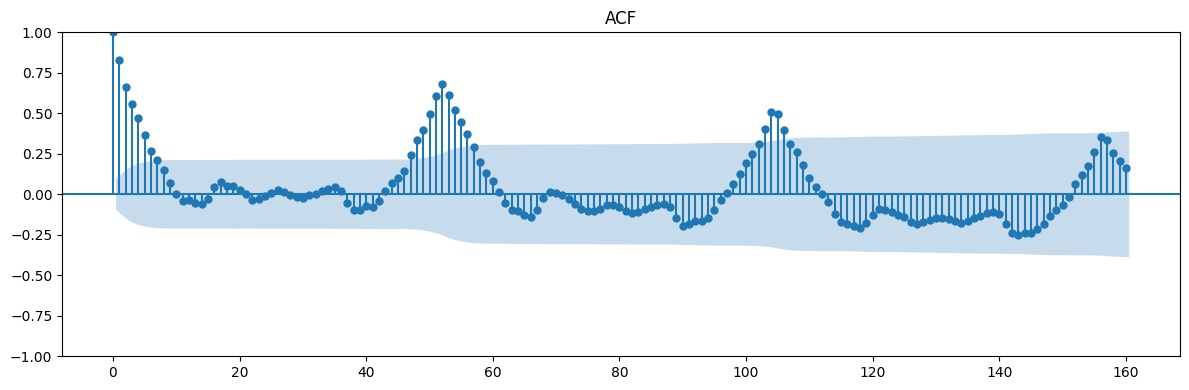

In [7]:
fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(train, lags=160, ax=ax)

ax.set_title("ACF")
plt.tight_layout()
plt.show()

### Stationarity Analysis

The following statistical tests are applied:

- Augmented Dickey-Fuller (ADF)
- KPSS test

### Interpretation

- ADF: H0 = non-stationary
- KPSS: H0 = stationary

Both tests suggest stationarity under their respective assumptions, although additional diagnostics indicate that the series is not fully stationary in practice.

In [8]:
dftest = adfuller(train, autolag = 'AIC')

print("1. ADF : ",dftest[0])
print("P-Value : ", dftest[1])

stat, p_value, lags, crit = kpss(train, regression='c', nlags='auto')

print("\n2. KPSS :", stat)
print("P-value:", p_value)

1. ADF :  -3.769741283038257
P-Value :  0.003232524724397349

2. KPSS : 0.36649386555803215
P-value: 0.09159747174222752


### Descriptive Analysis

To complement the statistical tests, the following are analyzed:

- Rolling mean
- Rolling variance

Results:

- The mean is not constant over time
- The variance shows noticeable fluctuations

This suggests that the series is not fully stationary in practice.

In [9]:
print("Global mean (train):", train.mean())
print("Global variance (train):", train.var())

yearly_mean = train.resample('YE').mean()
yearly_var = train.resample('YE').var()

print("\n Mean per year:")
print(yearly_mean)

print("\nVariance per year:")
print(yearly_var)

Global mean (train): 9717.021550219348
Global variance (train): 8116486.9643412

 Mean per year:
date
2012-12-31     7580.964797
2013-12-31     8908.871476
2014-12-31    10051.712922
2015-12-31    11190.123653
2016-12-31    10972.816840
2017-12-31    10719.413890
2018-12-31     9176.220134
2019-12-31     9187.526731
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64

Variance per year:
date
2012-12-31    4.165859e+06
2013-12-31    4.024630e+06
2014-12-31    6.609617e+06
2015-12-31    9.100379e+06
2016-12-31    9.947513e+06
2017-12-31    8.912911e+06
2018-12-31    5.811719e+06
2019-12-31    6.639339e+06
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64


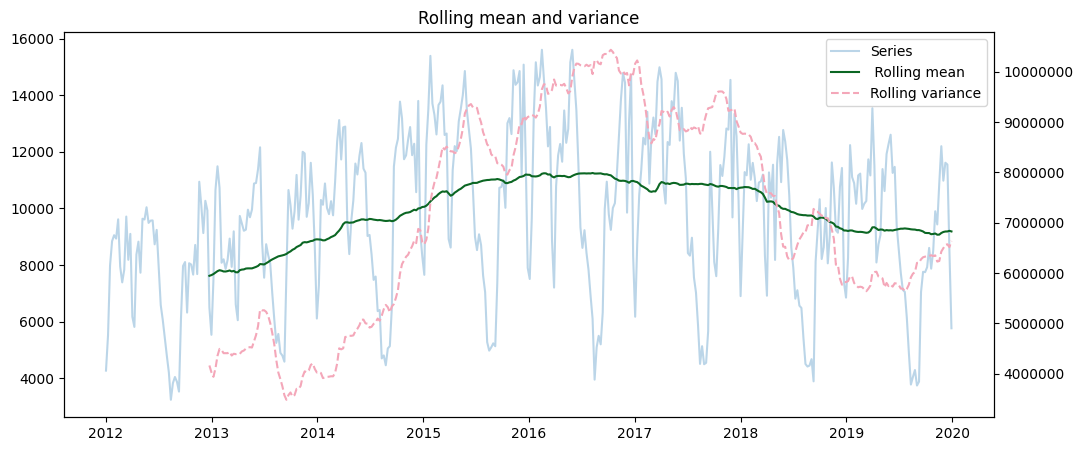

In [10]:
rolling_mean = train.rolling(52).mean()
rolling_var = train.rolling(52).var()

fig, ax1 = plt.subplots(figsize=(12,5))
l1, = ax1.plot(train, alpha=0.3, label='Series')
l2, = ax1.plot(rolling_mean, label=' Rolling mean', color=COLOR_GREEN, linewidth=1.5)

ax2 = ax1.twinx()
l3, = ax2.plot(rolling_var, linestyle='--', label='Rolling variance', color=COLOR_PINK, linewidth=1.5)
ax2.ticklabel_format(style='plain', axis='y')

lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

plt.title("Rolling mean and variance")
plt.show()

### Seasonal Differencing Check

To further assess whether seasonal differencing is appropriate, the series after applying one seasonal difference, is compared with the original series, and the ACF is examined again.

After applying seasonal differencing, the annual repeating pattern is substantially attenuated, and the seasonal peaks in the ACF become notably weaker. This supports the choice of seasonal differencing of order one, D = 1.

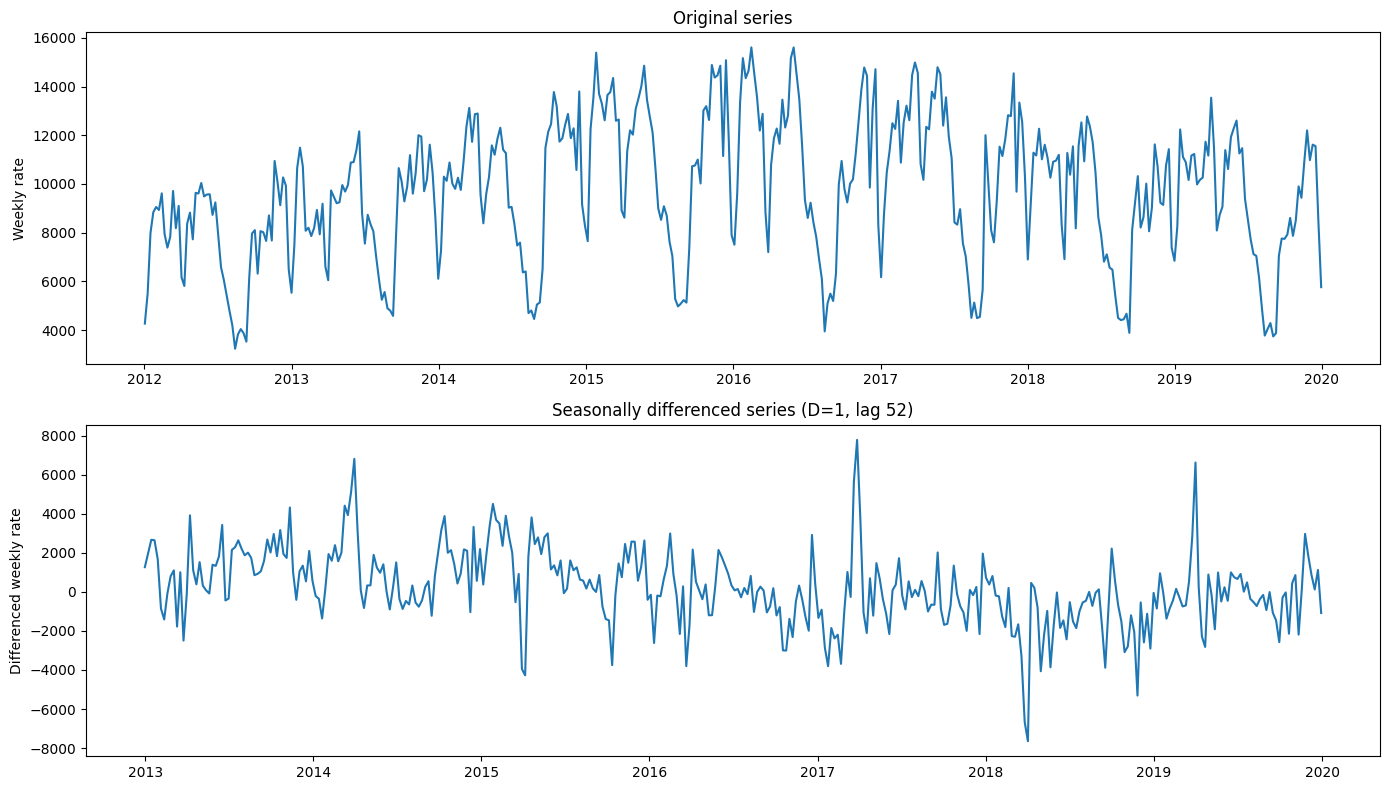

In [11]:
serie_D1 = train.diff(52).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(train)
axes[0].set_title("Original series")
axes[0].set_ylabel("Weekly rate")

axes[1].plot(serie_D1)
axes[1].set_title("Seasonally differenced series (D=1, lag 52)")
axes[1].set_ylabel("Differenced weekly rate")

plt.tight_layout()
plt.show()

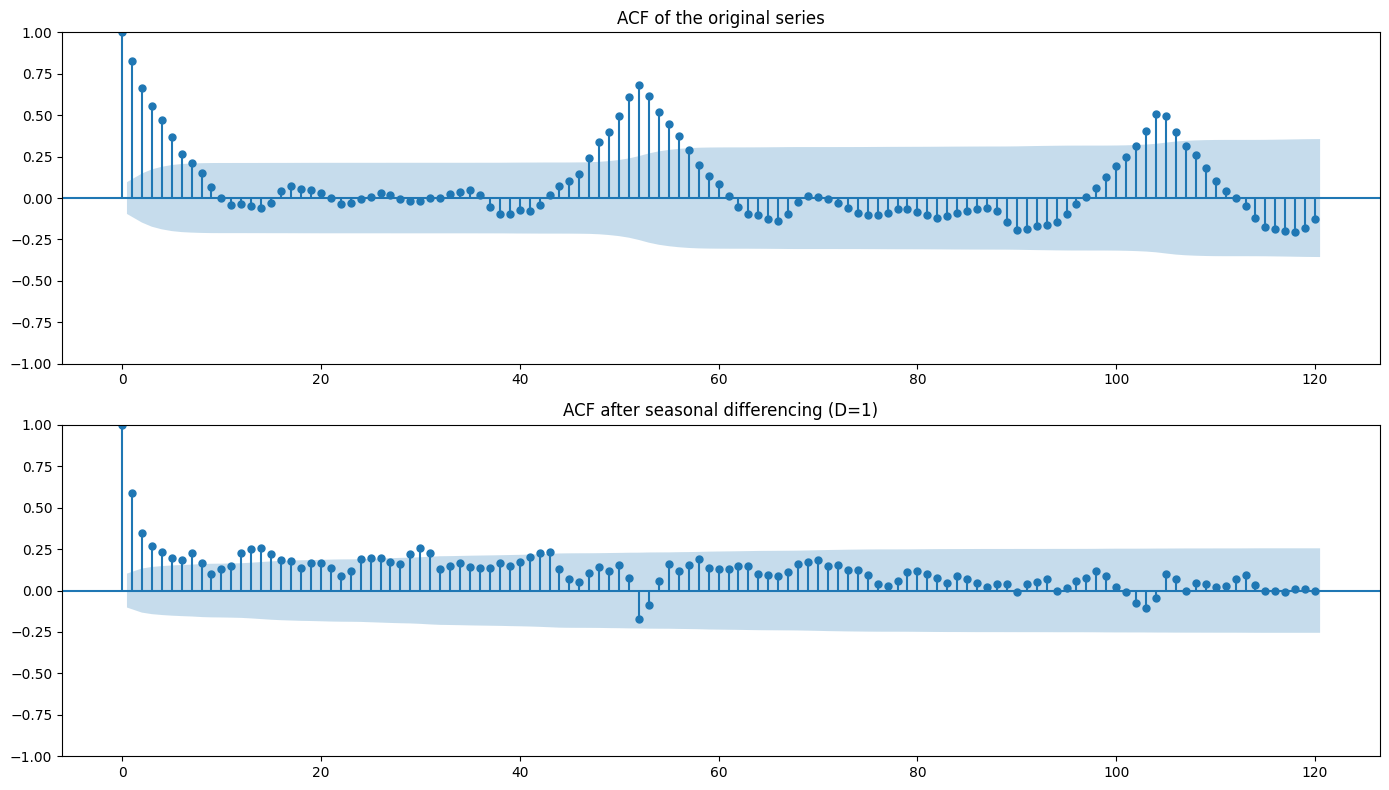

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(train.dropna(), lags=120, ax=axes[0])
axes[0].set_title("ACF of the original series")

plot_acf(serie_D1, lags=120, ax=axes[1])
axes[1].set_title("ACF after seasonal differencing (D=1)")

plt.tight_layout()
plt.show()

### Differencing Selection

Although ADF and KPSS suggest stationarity, additional analysis indicates that the mean is not fully stable over time. In particular, the rolling mean still shows some variation across the training period, and after applying only seasonal differencing, the ACF continues to display noticeable short-term persistence.

Given the conflicting evidence from formal tests and descriptive diagnostics, a first-order non-seasonal difference is also adopted. After applying both regular and seasonal differencing, the dependence structure becomes substantially more stable, and the ACF/PACF do not show clear signs of severe over-differencing.

This transformation stabilizes the mean structure and makes the series more suitable for SARIMA modeling.

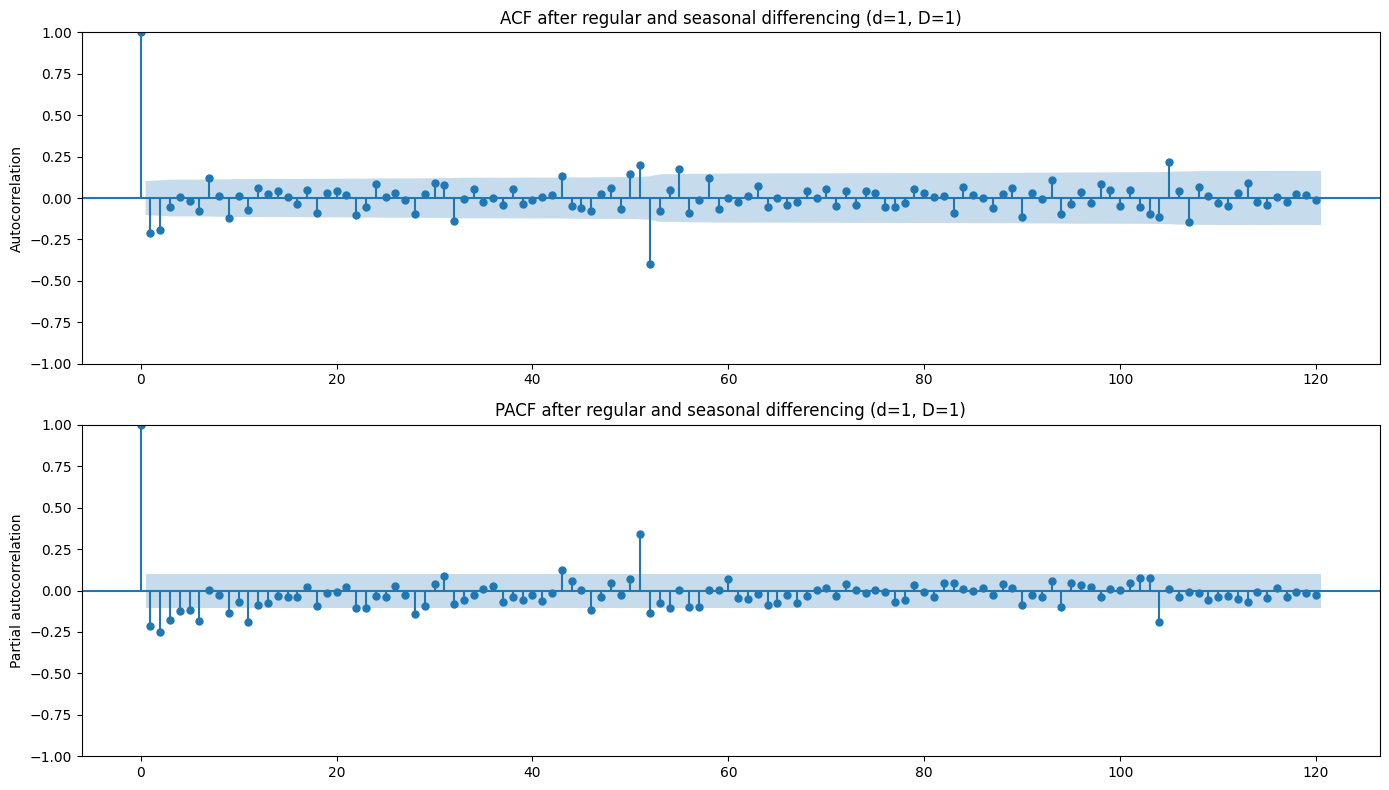

In [13]:
serie_d1D1 = serie_D1.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(serie_d1D1, lags=120, ax=axes[0])
axes[0].set_title("ACF after regular and seasonal differencing (d=1, D=1)")
axes[0].set_ylabel("Autocorrelation")

plot_pacf(serie_d1D1, lags=120, ax=axes[1])
axes[1].set_title("PACF after regular and seasonal differencing (d=1, D=1)")
axes[1].set_ylabel("Partial autocorrelation")

plt.tight_layout()
plt.show()

## Model Selection

I test several SARIMA models based on ACF/PACF insights and compare them using AIC.

Each model is fitted using the training data.

In [14]:
models = [
    ((1,1,1), (0,1,1,52)),
    ((2,1,1), (0,1,1,52)),
    ((1,1,2), (0,1,1,52)),
    ((2,1,2), (0,1,1,52)),
    ((1,1,2), (0,1,0,52)),
    ((1,1,2), (1,1,1,52)),
    ((1,1,1), (1,1,1,52)),
    ((2,1,2), (1,1,1,52)),
]

best_aic = float("inf")
best_model = None

for order, seasonal_order in models:
    try:
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        results = model.fit(disp=False)
        
        print(f"Model SARIMA{order}{seasonal_order}")
        print(f"AIC: {results.aic}")
        print("-"*40)
        
        if results.aic < best_aic:
            best_aic = results.aic
            best_model = (order, seasonal_order)
    
    except:
        print(f"Error in model SARIMA{order}{seasonal_order}")

print("\n Best model:")
print(best_model)
print("AIC:", best_aic)


Model SARIMA(1, 1, 1)(0, 1, 1, 52)
AIC: 5354.6242473721895
----------------------------------------
Model SARIMA(2, 1, 1)(0, 1, 1, 52)
AIC: 5356.125922960049
----------------------------------------
Model SARIMA(1, 1, 2)(0, 1, 1, 52)
AIC: 5338.75966817522
----------------------------------------


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Model SARIMA(2, 1, 2)(0, 1, 1, 52)
AIC: 5340.21408633495
----------------------------------------
Model SARIMA(1, 1, 2)(0, 1, 0, 52)
AIC: 6355.210915877795
----------------------------------------
Model SARIMA(1, 1, 2)(1, 1, 1, 52)
AIC: 5339.476920526368
----------------------------------------
Model SARIMA(1, 1, 1)(1, 1, 1, 52)
AIC: 5395.866516588091
----------------------------------------
Model SARIMA(2, 1, 2)(1, 1, 1, 52)
AIC: 5366.182724510908
----------------------------------------

 Best model:
((1, 1, 2), (0, 1, 1, 52))
AIC: 5338.75966817522


In [15]:
model1 = SARIMAX(train,
                order=(1,1,2),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result1 = model1.fit()
print(result1.summary())

                                      SARIMAX Results                                       
Dep. Variable:                        taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 52)   Log Likelihood               -2664.380
Date:                              Sat, 11 Apr 2026   AIC                           5338.760
Time:                                      00:32:22   BIC                           5357.443
Sample:                                  01-02-2012   HQIC                          5346.228
                                       - 12-30-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4630      0.097      4.751      0.000       0.272       0.654
ma.L1         -0.88

In [16]:
model2 = SARIMAX(train,
                order=(1,1,2),
                seasonal_order=(1,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result2 = model2.fit()
print(result2.summary())

                                      SARIMAX Results                                       
Dep. Variable:                        taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(1, 1, 2)x(1, 1, [1], 52)   Log Likelihood               -2663.738
Date:                              Sat, 11 Apr 2026   AIC                           5339.477
Time:                                      00:32:29   BIC                           5361.896
Sample:                                  01-02-2012   HQIC                          5348.439
                                       - 12-30-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4483      0.098      4.563      0.000       0.256       0.641
ma.L1         -0.87

In [17]:
model3 = SARIMAX(train,
                order=(2,1,2),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result3 = model3.fit()
print(result3.summary())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                        taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 52)   Log Likelihood               -2664.107
Date:                              Sat, 11 Apr 2026   AIC                           5340.214
Time:                                      00:32:39   BIC                           5362.634
Sample:                                  01-02-2012   HQIC                          5349.176
                                       - 12-30-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9612      1.509      0.637      0.524      -1.996       3.919
ar.L2         -0.24

In [18]:
model4 = SARIMAX(train,
                order=(1,1,1),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result4 = model4.fit()
print(result4.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 52)   Log Likelihood               -2673.312
Date:                            Sat, 11 Apr 2026   AIC                           5354.624
Time:                                    00:32:47   BIC                           5369.583
Sample:                                01-02-2012   HQIC                          5360.604
                                     - 12-30-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5098      0.049     10.326      0.000       0.413       0.607
ma.L1         -0.9461      0.021   

## Model Selection for Residual Validation

Among the initial candidate models, a detailed evaluation was carried out based on information criteria, parameter significance, and overall model adequacy.

From this first comparison, three models were retained as the strongest candidates for further analysis. One additional model was discarded at this stage because it included non-significant parameters and presented convergence issues, making its estimates less reliable.

To perform a more rigorous residual assessment, the diagnostic analysis was conducted after excluding the initial burn-in period of each fitted model. This step is justified by the state-space representation used in SARIMA estimation, where the first residuals may be affected by filter initialization and therefore may not be fully representative of the stable residual behavior of the model. For this reason, residual diagnostics were based only on the post–burn-in residuals.

Burn-in used: 108


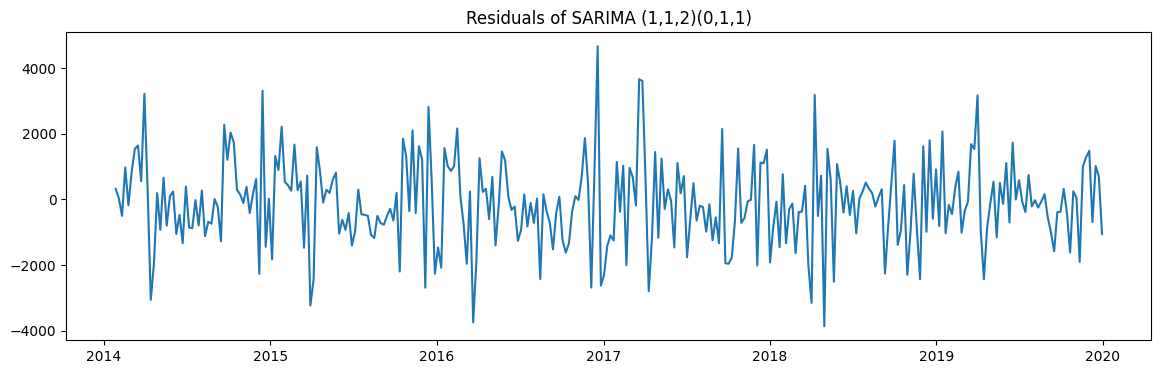

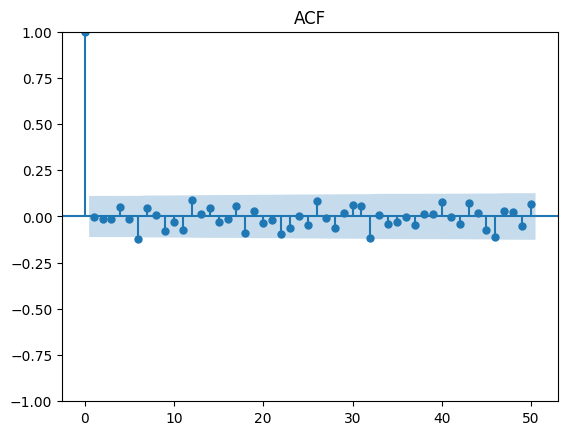


 Ljung Box
      lb_stat  lb_pvalue
10   8.654779   0.565149
20  18.522555   0.553026
30  28.810069   0.527590

Mean of residuals: -122.65672480396508
Std of residuals: 1303.107956233982
Relative mean (|mean| / std): 0.09412629568961148


In [19]:
residuals= result1.resid.dropna()
burn = max(result1.loglikelihood_burn, result1.filter_results.nobs_diffuse)

print(f"Burn-in used: {burn}")
residual1 = residuals.iloc[burn:].copy()

plt.figure(figsize=(14,4))
plt.plot(residual1)
plt.title("Residuals of SARIMA (1,1,2)(0,1,1)")
plt.show()

plot_acf(residual1, lags=50)
plt.title("ACF")
plt.show()

print("\n Ljung Box")
print(acorr_ljungbox(residual1, lags=[10, 20, 30], return_df=True))

mean_resid = residual1.mean()
std_resid = residual1.std()

ratio = abs(mean_resid) / std_resid

print("\nMean of residuals:", mean_resid)
print("Std of residuals:", std_resid)
print("Relative mean (|mean| / std):", ratio)

Burn-in used: 108


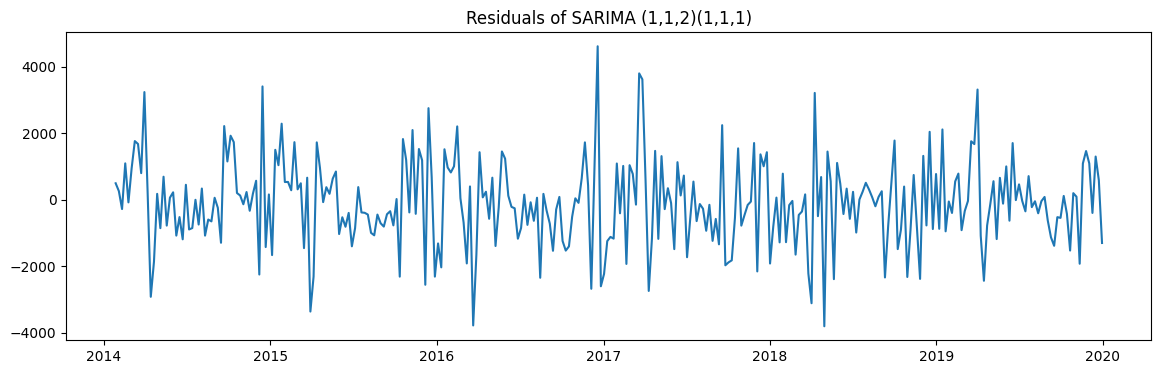

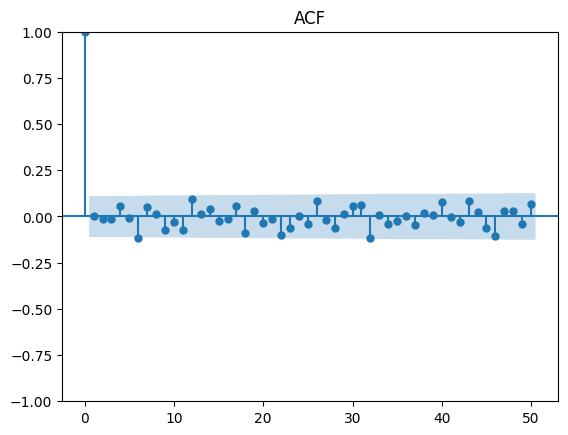


Ljung-Box
      lb_stat  lb_pvalue
10   8.319906   0.597620
20  18.217947   0.573054
30  28.593515   0.539016

Mean of residuals: -109.49145895153957
Std of residuals: 1301.5076584900062
Relative mean (|mean| / std): 0.08412663439765715


In [20]:
residuals= result2.resid.dropna()
burn = max(result2.loglikelihood_burn, result2.filter_results.nobs_diffuse)

print(f"Burn-in used: {burn}")
residual2 = residuals.iloc[burn:].copy()

plt.figure(figsize=(14,4))
plt.plot(residual2)
plt.title("Residuals of SARIMA (1,1,2)(1,1,1)")
plt.show()

plot_acf(residual2, lags=50)
plt.title("ACF")
plt.show()

print("\nLjung-Box")
print(acorr_ljungbox(residual2, lags=[10, 20, 30], return_df=True))

mean_resid = residual2.mean()
std_resid = residual2.std()

ratio = abs(mean_resid) / std_resid

print("\nMean of residuals:", mean_resid)
print("Std of residuals:", std_resid)
print("Relative mean (|mean| / std):", ratio)

Burn-in used: 107


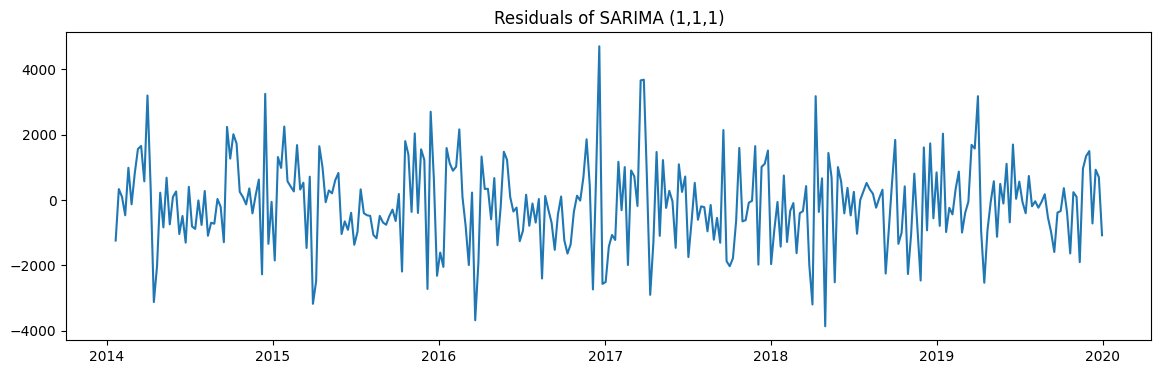

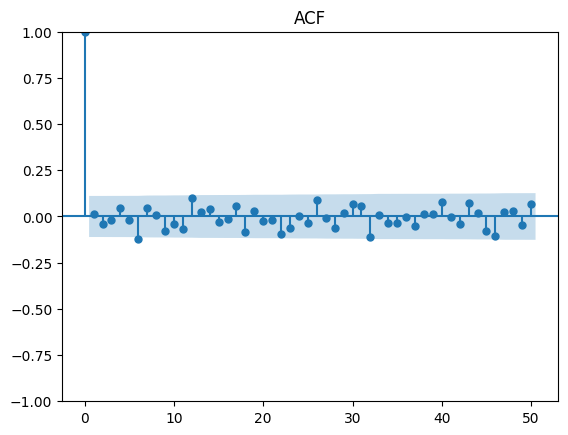


Ljung-Box
      lb_stat  lb_pvalue
10   9.474886   0.487704
20  19.336789   0.500041
30  29.860314   0.472824

Mean of residuals: -123.14899502092321
Std of residuals: 1304.30069078186
Relative mean (|mean| / std): 0.09441764149270045


In [21]:
residuals= result4.resid.dropna()
burn = max(result4.loglikelihood_burn, result4.filter_results.nobs_diffuse)

print(f"Burn-in used: {burn}")
residual4 = residuals.iloc[burn:].copy()

plt.figure(figsize=(14,4))
plt.plot(residual4)
plt.title("Residuals of SARIMA (1,1,1)")
plt.show()

plot_acf(residual4, lags=50)
plt.title("ACF")
plt.show()

print("\nLjung-Box")
print(acorr_ljungbox(residual4, lags=[10, 20, 30], return_df=True))

mean_resid = residual4.mean()
std_resid = residual4.std()

ratio = abs(mean_resid) / std_resid

print("\nMean of residuals:", mean_resid)
print("Std of residuals:", std_resid)
print("Relative mean (|mean| / std):", ratio)

### Residual Validation Results

The three retained models show reasonably adequate residual behavior after the burn-in adjustment. In all cases, the residual autocorrelation is low, the residual mean remains close to zero, and the Ljung–Box test does not provide evidence against the white-noise assumption at the considered lags. Although normality is not perfect, this is not unusual in practical time series applications and does not invalidate the overall adequacy of the models.

Since the three candidates display fairly similar residual diagnostics, their final comparison is supported by a small out-of-sample forecasting evaluation based on predictive accuracy measures such as MAE and RMSE.

In [22]:
# Model 1
pred1 = result1.get_forecast(steps=len(test))
pred1_mean = pred1.predicted_mean

mae1 = mean_absolute_error(test, pred1_mean)
rmse1= root_mean_squared_error(test, pred1_mean)

# Model 2
pred2 = result2.get_forecast(steps=len(test))
pred2_mean = pred2.predicted_mean

mae2 = mean_absolute_error(test, pred2_mean)
rmse2= root_mean_squared_error(test, pred2_mean)

# Model 4
pred4 = result4.get_forecast(steps=len(test))
pred4_mean = pred4.predicted_mean

mae4 = mean_absolute_error(test, pred4_mean)
rmse4= root_mean_squared_error(test, pred4_mean)


print("Model (1,1,2)(0,1,1) → MAE:", mae1, "RMSE:", rmse1)
print("Model (1,1,2)(1,1,1) → MAE:", mae2, "RMSE:", rmse2)
print("Model (1,1,1)(0,1,1) → MAE:", mae4, "RMSE:", rmse4)

Model (1,1,2)(0,1,1) → MAE: 3172.5191758742617 RMSE: 4109.254416673882
Model (1,1,2)(1,1,1) → MAE: 3240.4741688350873 RMSE: 4187.681395457051
Model (1,1,1)(0,1,1) → MAE: 3167.841257580462 RMSE: 4099.871500851928


### Final Model Selection

Although the candidate models show very similar performance in terms of AIC, residual diagnostics, and forecasting accuracy measured through MAE and RMSE, the differences between them are small.

The SARIMA(1,1,2)(0,1,1,52) model achieves the lowest AIC among the selected candidates. However, this advantage is not supported by a clearly better residual validation or by a meaningful improvement in the MAE and RMSE values. Moreover, the additional non-seasonal moving-average term is not statistically significant, which makes the increase in complexity less justified.

By contrast, the SARIMA(1,1,1)(0,1,1,52) model provides a simpler and more interpretable specification, while still showing adequate residual behavior and a forecasting performance very similar to that of the more complex alternative.

Therefore, the SARIMA(1,1,1)(0,1,1,52) model is selected as the final model for this series, following the principle of parsimony.

### Forecasting
Once the model has been validated, I generate forecasts using the test set horizon.

The objective is to evaluate how well the model captures:
- the overall trend
- the seasonal pattern
- the variability of the series

Predictions are accompanied by prediction intervals, which reflect the uncertainty of the model.

In [23]:
#Final model
model = SARIMAX(train,
                order=(1,1,1),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit()

pred = result.get_forecast(steps=len(test))
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()   

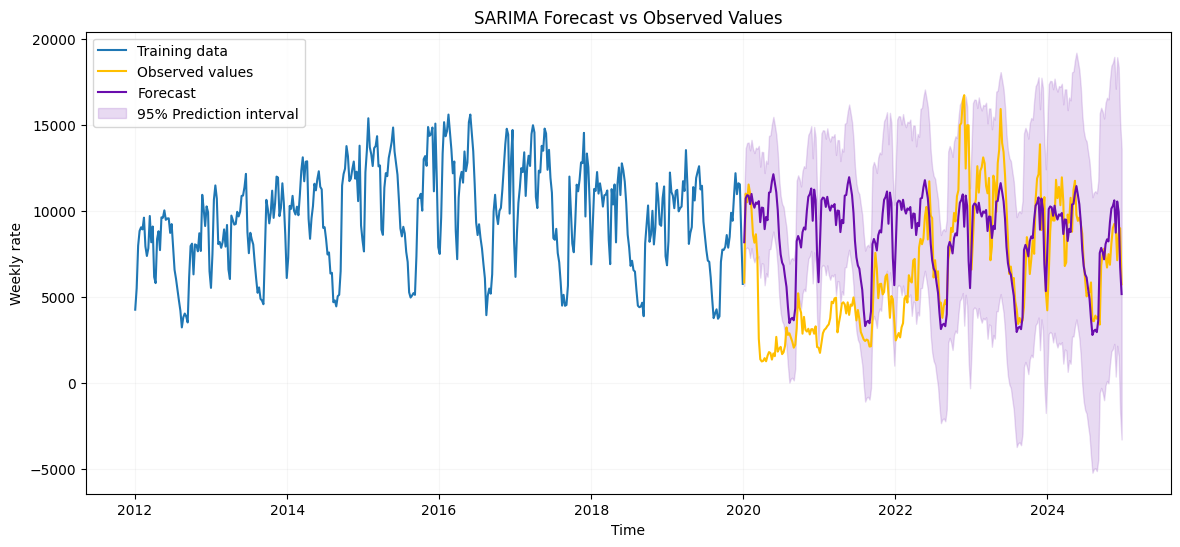

In [24]:
plt.figure(figsize=(14,6))

plt.plot(train, label='Training data', color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label='Observed values', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Forecast', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='95% Prediction interval')

plt.legend()
plt.title("SARIMA Forecast vs Observed Values")
plt.xlabel("Time")
plt.ylabel("Weekly rate")
plt.grid(alpha=0.1)
plt.show()

In [25]:
mae_total = mean_absolute_error(test, pred_mean)
rmse_total = root_mean_squared_error(test, pred_mean)

covTotal = ((test >= pred_ci.iloc[:, 0]) & (test <= pred_ci.iloc[:, 1])).mean()

print("TOTAL")
print("MAE:", mae_total)
print("RMSE:", rmse_total)
print("Coverage:", covTotal)

TOTAL
MAE: 3167.841257580462
RMSE: 4099.871500851928
Coverage: 0.7153846153846154


### Forecast Evaluation

To quantitatively evaluate the forecasting performance, I compute error metrics such as:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

These metrics measure the difference between observed and predicted values, allowing me to assess the accuracy of the model.

The empirical coverage of the 95% prediction intervals is about 0.72, which is below the nominal level and suggests that forecast uncertainty is underestimated.

To further investigate this issue, the test period is divided into two subperiods:
- COVID period
- Post-COVID period

This allows me to analyze whether the model behaves differently under structural changes in the data.

In [26]:
test_covid = test["2020":"2021"]
test_post = test["2022":"2024"]

pred_covid = pred_mean["2020":"2021"]
pred_post = pred_mean["2022":"2024"]

ci_covid = pred_ci.loc["2020":"2021"]
ci_post = pred_ci.loc["2022":"2024"]

 
mae_covid = mean_absolute_error(test_covid, pred_covid)
rmse_covid = root_mean_squared_error(test_covid, pred_covid)

cov_covid = ((test_covid >= ci_covid.iloc[:, 0]) & (test_covid <= ci_covid.iloc[:, 1])).mean()

print("\nCOVID (2020-2021)")
print("MAE:", mae_covid)
print("RMSE:", rmse_covid)
print("Coverage:", cov_covid)


mae_post = mean_absolute_error(test_post, pred_post)
rmse_post = root_mean_squared_error(test_post, pred_post)

cov_post = ((test_post >= ci_post.iloc[:, 0]) & (test_post <= ci_post.iloc[:, 1])).mean()

print("\nPOST-COVID (2022-2024)")
print("MAE:", mae_post)
print("RMSE:", rmse_post)
print("Coverage:", cov_post)


COVID (2020-2021)
MAE: 4885.054482506688
RMSE: 5578.518765508442
Coverage: 0.38461538461538464

POST-COVID (2022-2024)
MAE: 2023.0324409629777
RMSE: 2695.9839504486154
Coverage: 0.9358974358974359


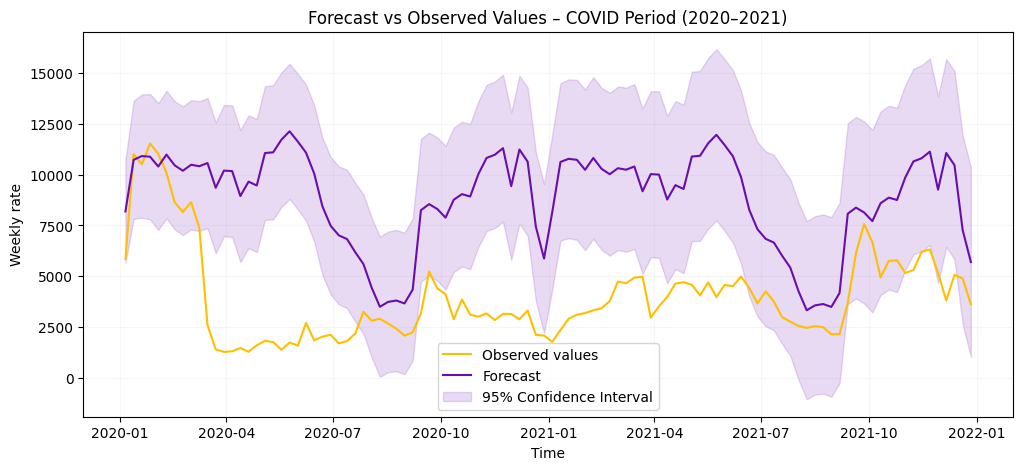

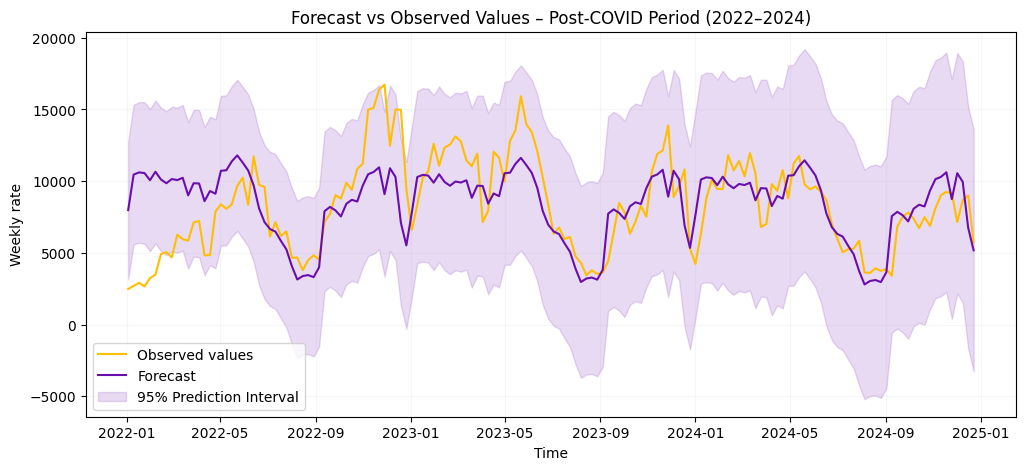

In [27]:
plt.figure(figsize=(12,5))

plt.plot(test_covid, label='Observed values', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_covid, label='Forecast', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_covid.index,
                 ci_covid.iloc[:, 0],
                 ci_covid.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='95% Confidence Interval')

plt.title("Forecast vs Observed Values – COVID Period (2020–2021)")
plt.xlabel("Time")
plt.ylabel("Weekly rate") 
plt.legend()
plt.grid(alpha=0.1)
plt.show()


plt.figure(figsize=(12,5))

plt.plot(test_post, label='Observed values', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_post, label='Forecast', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_post.index,
                 ci_post.iloc[:, 0],
                 ci_post.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='95% Prediction Interval')

plt.title("Forecast vs Observed Values – Post-COVID Period (2022–2024)")
plt.xlabel("Time")
plt.ylabel("Weekly rate")
plt.legend()
plt.grid(alpha=0.1)
plt.show()

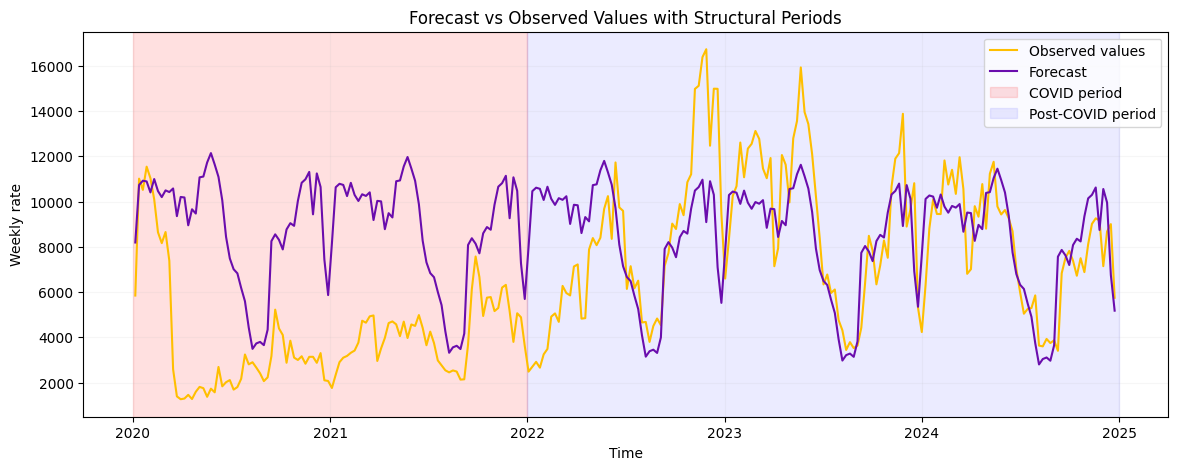

In [28]:
plt.figure(figsize=(14,5))

plt.plot(test, label='Observed values', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Forecast', color=COLOR_FORECAST, linewidth=1.5)

plt.axvspan(pd.to_datetime("2020-01-01"),
            pd.to_datetime("2021-12-31"),
            color='red', alpha=0.12, label='COVID period')

plt.axvspan(pd.to_datetime("2022-01-01"),
            pd.to_datetime("2024-12-31"),
            color='blue', alpha=0.08, label='Post-COVID period')

plt.legend()
plt.title("Forecast vs Observed Values with Structural Periods")
plt.xlabel("Time")
plt.ylabel("Weekly rate")
plt.grid(alpha=0.1)

plt.show()

### Visual Analysis

During the COVID period (2020–2021), the observed values show a sharp decline and structural disruption, which is not captured by the model. As a result, the forecasts systematically overestimate the true values, leading to larger prediction errors and low coverage.

This behavior reflects a structural break caused by external factors (lockdowns, social distancing, reduced transmission), which were not present in the training data.

In contrast, during the post-COVID period (2022–2024), the series recovers a more regular seasonal pattern. The model is then able to align closely with the observed values, capturing both the level and seasonal fluctuations with good accuracy.

This highlights a key property of SARIMA models: they perform well under stable conditions but struggle in the presence of sudden structural changes, making them useful not only for forecasting but also for detecting anomalous periods.